In [1]:
import os
import cv2
import gdown
import torch
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Any, Dict, Tuple
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
import wandb
from IPython.display import clear_output
from PIL import Image
from sklearn.metrics import (
    RocCurveDisplay,
    auc,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from tqdm.notebook import tqdm, trange

import optuna
from optuna.samplers import TPESampler


# url = "https://drive.google.com/uc?id=1DHuQ3DBsgab6NtZIZfAKUHS2rW3-vmtb"
# output = "dataset"
# gdown.download(url, output, quiet=False)

# file_id = '1DHuQ3DBsgab6NtZIZfAKUHS2rW3-vmtb'
# gdown.download(f'https://drive.google.com/uc?id={file_id}', 'myfile.zip', quiet=False)
# zip_path = 'myfile.zip'
# extract_path = './extracted_files/'

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# print(f"Файл распакован в: {extract_path}")

In [3]:
cd ..

/mnt/tank/scratch/rgurtsiev/workflow


/mnt/tank/scratch/rgurtsiev/miniconda3/envs/my_env/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


# Create Dataset and DataLoader

In [5]:
class ImageProcessor:
    def __init__(self, image_shape=None):
        self.image_shape = image_shape

    def compute_common_size(self, images_dir, image_ids):
        shapes = []
        for image_id in image_ids:
            image_path = os.path.join(images_dir, image_id)
            image = cv2.imread(image_path)
            shapes.append(image.shape)
        shapes = np.array(shapes)
        common_height = int(np.quantile(shapes[:, 0], 0.99))
        common_width = int(np.quantile(shapes[:, 1], 0.99))
        return common_height, common_width

    def resize(self, image):
        if not self.image_shape:
            raise ValueError("Image shape not set for resizing.")
        common_height, common_width = self.image_shape
        return cv2.resize(image, (common_width, common_height))

    def normalize(self, image):
        return cv2.normalize(image, None, 0, 1.0, cv2.NORM_MINMAX, dtype=cv2.CV_32F)

    def to_tensor(self, image):
        tensor_image = torch.tensor(image, dtype=torch.float32)
        return tensor_image.permute(2, 0, 1) 


class LabelLoader:
    @staticmethod
    def load_labels(labels_path):
        labels = {}
        if os.path.exists(labels_path):
            with open(labels_path) as f:
                lines = f.readlines()
            for line in lines:
                path, label = line.split()
                labels[path] = int(label)
        return labels


class CustomDataset(Dataset):
    def __init__(self, split="train", dataset_dir="dataset", image_shape=None, transforms=None):
        self.dataset_dir = dataset_dir
        self.split = split
        self.root_dir = os.path.join(self.dataset_dir, self.split)
        self.transforms = transforms
        
        self.images_dir = os.path.join(self.root_dir, "imgs" if split == "test" else "")
        self.image_ids = [
            fname for fname in os.listdir(self.images_dir) if fname.endswith(".jpg")
        ]

        self.labels = LabelLoader.load_labels(
            os.path.join(self.root_dir, "test_annotation.txt")
        )

        self.processor = ImageProcessor(image_shape)
        if not image_shape:
            self.processor.image_shape = self.processor.compute_common_size(
                self.images_dir, self.image_ids
            )

    @property
    def image_shape(self):
        return self.processor.image_shape

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_path = os.path.join(self.images_dir, image_id)
        image = cv2.imread(image_path)

        image = self.processor.normalize(image)
        image = self.processor.resize(image)
        image = self.processor.to_tensor(image)

        if self.transforms:
            image = self.transforms(image)

        label = self.labels.get(image_id, 0)
        return image, label

In [6]:
# Создадим datset и dataloader

RANDOM_SEED = 0
SPLIT_RATIO = 0.05
BATCH_SIZE = 128
PROJECT = "hw_2"
np.random.seed(RANDOM_SEED)

train_dataset = CustomDataset("train")
proliv_dataset = CustomDataset("proliv", image_shape=train_dataset.image_shape)
test_dataset = CustomDataset("test", image_shape=train_dataset.image_shape)

val_split = int(np.floor(SPLIT_RATIO * len(train_dataset)))
indices = list(range(len(train_dataset)))
np.random.seed(RANDOM_SEED)
np.random.shuffle(indices)
train_sampler = SubsetRandomSampler(indices[val_split:])
val_sampler = SubsetRandomSampler(indices[:val_split])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler)
val_loader = DataLoader(train_dataset, batch_size=1, sampler=val_sampler)

proliv_loader = DataLoader(proliv_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# Визуализируем

In [11]:
def display(image: torch.Tensor):
    image = (image * 255).type(torch.int).transpose(0, 2)
    plt.imshow(image)
    
def visualize(model, batch):
    model.to("cpu")
    batch.to("cpu")
    display(batch[0])
    plt.show()
    model.eval()
    with torch.no_grad():
        output = model(batch)[0]
        display(output)
        loss = ((batch - output) ** 2).sum()
        print(f"Loss: {loss:.2f}")

In [145]:
train_dataset[0][0].shape

torch.Size([3, 33, 53])

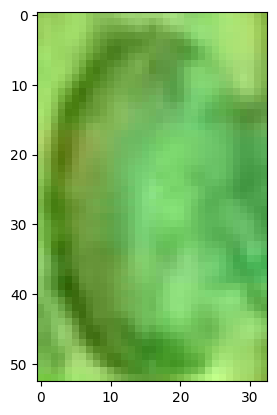

In [12]:
display(train_dataset[0][0])

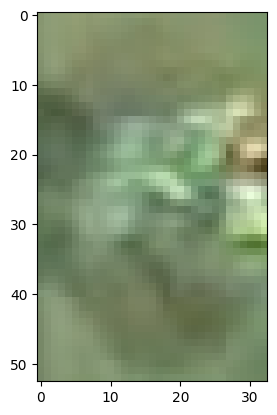

In [13]:
display(proliv_dataset[0][0])

# Model

In [50]:
# AE
class Encoder(nn.Module):
    def __init__(self, input_dims, latent_dims):
        super(Encoder, self).__init__()
        self.linear1 = nn.Linear(input_dims, 512)
        self.linear2 = nn.Linear(512, latent_dims)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        return self.linear2(x)

class Decoder(nn.Module):
    def __init__(self, out_dims, latent_dims, shape):
        super(Decoder, self).__init__()
        self.shape = shape
        self.linear1 = nn.Linear(latent_dims, 512)
        self.linear2 = nn.Linear(512, out_dims)

    def forward(self, z):
        z = F.relu(self.linear1(z))
        z = torch.sigmoid(self.linear2(z))
        return z.reshape((-1, *self.shape))

class Autoencoder(nn.Module):
    def __init__(self, shape, latent_dims):
        super(Autoencoder, self).__init__()
        self.shape = shape
        self.latent_dims = latent_dims
        self.input_dims = torch.prod(torch.tensor(self.shape))
        self.encoder = Encoder(self.input_dims, self.latent_dims)
        self.decoder = Decoder(self.input_dims, self.latent_dims, self.shape)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


# VAE
class VariationalEncoder(nn.Module):
    def __init__(self, input_dims, latent_dims):
        super(VariationalEncoder, self).__init__()
        self.linear1 = nn.Linear(input_dims, 512)
        self.linear2 = nn.Linear(512, latent_dims)
        self.linear3 = nn.Linear(512, latent_dims)

        self.N = torch.distributions.Normal(0, 1)
        self.N.loc = self.N.loc.to(device) 
        self.N.scale = self.N.scale.to(device)
        self.kl = 0

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        mu = self.linear2(x)
        sigma = torch.exp(self.linear3(x))
        z = mu + sigma * self.N.sample(mu.shape)
        self.kl = (sigma**2 + mu**2 - torch.log(sigma) - 1 / 2).sum()
        return z

class VariationalAutoencoder(nn.Module):
    def __init__(self, shape, latent_dims):
        super(VariationalAutoencoder, self).__init__()
        self.shape = shape
        self.latent_dims = latent_dims
        self.input_dims = torch.prod(torch.tensor(self.shape))
        self.encoder = VariationalEncoder(self.input_dims, self.latent_dims)
        self.decoder = Decoder(self.input_dims, self.latent_dims, self.shape)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [51]:
device = 'cuda'

latent_dims = 2
shape = next(iter(train_loader))[0].shape
autoencoder = Autoencoder(shape[1:], latent_dims)
vae = VariationalAutoencoder(shape[1:], latent_dims).to(device)

# Metrics

In [52]:
def compute_metrics(y_true, losses, th):
    y_pred = [1 if loss > th else 0 for loss in losses]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)
    roc_auc = roc_auc_score(y_true, y_pred)
    return tpr, tnr, roc_auc

def det_threshold(model, val_loader, proliv_loader, plot=True):
    model.to(device)
    val_losses = eval(model, val_loader)
    proliv_losses = eval(model, proliv_loader)
    y_true = np.hstack((np.zeros(len(val_losses)), np.ones(len(proliv_losses))))
    losses = np.hstack((val_losses, proliv_losses))
    fpr, tpr, thresholds = roc_curve(np.array(y_true), losses)
    roc_auc = auc(fpr, tpr)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    if plot:
        display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
        display.plot()
        plt.show()
    tpr, tnr, roc_auc = compute_metrics(y_true, losses, optimal_threshold)
    return optimal_threshold, tpr, tnr, roc_auc

def test_eval(model, data, y_true, th):
    losses = run_epoch(model, data, mode="eval")
    y_pred = [1 if loss > th else 0 for loss in losses]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)
    roc_auc = roc_auc_score(y_true, y_pred)
    return tpr, tnr, roc_auc

# Train

In [53]:
def run_epoch(model, data, mode="train", opt=None, show_pb=True):
    epoch_losses = []
    if show_pb:
        batches = tqdm(data)
    else:
        batches = data
    for x, y in batches:
        x = x.to(device)  # GPU
        if mode == "train":
            opt.zero_grad()
        x_hat = model(x)
        loss = ((x - x_hat) ** 2).sum() / data.batch_size
        epoch_losses.append(loss.item())
        if show_pb:
            batches.set_description(str(loss.item()))
        if mode == "train" and opt:
            loss.backward()
            opt.step()
    return epoch_losses


def train(
    model, data, lr=0.001, epochs=20, plot=True, pb_for_each_epoch=True, to_wandb=False
):
    model.to(device)
    model.train()
    loss_history = []
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    if not pb_for_each_epoch:
        epochs_range = trange(epochs)
    else:
        epochs_range = range(epochs)
    for epoch in epochs_range:
        if pb_for_each_epoch:
            print(f"Epoch: {epoch}")
        epoch_losses = run_epoch(
            model, data, mode="train", opt=opt, show_pb=pb_for_each_epoch
        )
        avg_epoch_loss = np.mean(epoch_losses)
        loss_history.append(avg_epoch_loss)
        if not pb_for_each_epoch:
            epochs_range.set_description(str(avg_epoch_loss))
        elif not plot:
            print(f"Train loss: {avg_epoch_loss}")

        if to_wandb:
            wandb.log({"loss": avg_epoch_loss})

        if plot:
            clear_output()
            print(f"Train loss: {avg_epoch_loss}")
            print("Loss curve")
            plt.plot(loss_history)
            plt.show()

    return model, loss_history


def eval(model, data):
    model.eval()
    losses = run_epoch(model, data, mode="eval")
    return losses

Train loss: 34.774836136744575
Loss curve


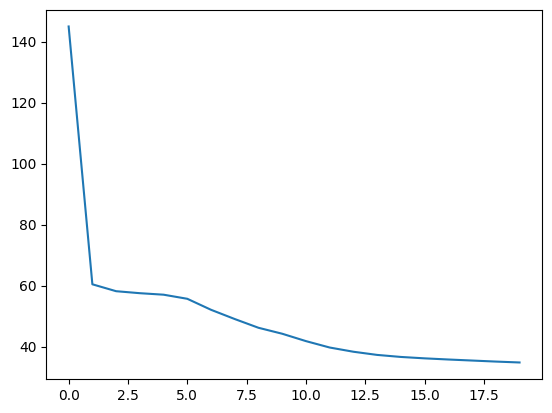

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/154 [00:00<?, ?it/s]

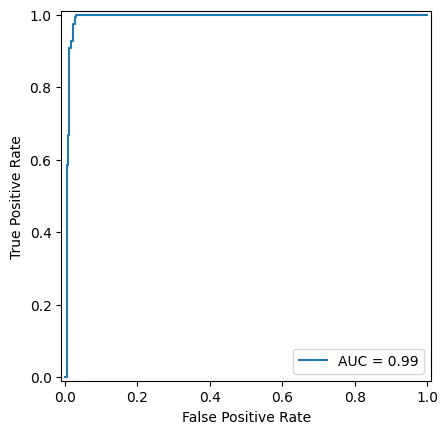

Evaluation on the test set ...


  0%|          | 0/3794 [00:00<?, ?it/s]

True Positive rate 0.915
True Neagtive rate: 0.733
ROC AUC score: 0.824


In [54]:
autoencoder, loss_history = train(autoencoder, train_loader)
th, _, _, _ = det_threshold(autoencoder, val_loader, proliv_loader)

print("Evaluation on the test set ...")
y_true = [int(b[1]) for b in list(test_loader)]
tpr, tnr, roc_auc = test_eval(autoencoder, test_loader, y_true, 82.41)
print(
    f"True Positive rate {tpr:.3f}\nTrue Neagtive rate: {tnr:.3f}\nROC AUC score: {roc_auc:.3f}"
)

# Подбор гиперпарметров

In [19]:
def parameters(trial):
    model = trial.suggest_categorical("model", ["AE", "VAE"])
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    epochs = trial.suggest_int("epochs", 10, 100)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256, 512, 600, 780, 1024])
    latent_dims = trial.suggest_categorical("latent_dims", [2, 4, 8, 16, 32, 64])

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, sampler=train_sampler
    )
    shape = next(iter(train_loader))[0].shape
    if model == "AE":
        model = Autoencoder(shape[1:], latent_dims)
    elif model == "VAE":
        model = VariationalAutoencoder(shape[1:], latent_dims)
    model.to(device)

    wandb.init(project=PROJECT, config={**trial.params})
    model, loss_history = train(
        model,
        train_loader,
        lr=learning_rate,
        epochs=epochs,
        plot=False,
        pb_for_each_epoch=False,
        to_wandb=True,
    )
    th, val_tpr, val_tnr, val_roc_auc = det_threshold(
        model, val_loader, proliv_loader, plot=False
    )
    y_true = [int(b[1]) for b in list(test_loader)]
    tpr, tnr, roc_auc = test_eval(model, test_loader, y_true, th)
    wandb.log(
        {
            "val_tpr": val_tpr,
            "val_tnr": val_tnr,
            "val_roc_auc": val_roc_auc,
            "tpr": tpr,
            "tnr": tnr,
            "roc_auc": roc_auc,
        }
    )
    wandb.finish()
    return roc_auc

In [14]:
optuna.logging.set_verbosity(optuna.logging.INFO)

sampler = TPESampler(seed=1)
study = optuna.create_study(
    study_name="proliv-deteсt", direction="maximize", sampler=sampler
)
study.optimize(parameters, n_trials=120)

[I 2025-01-14 11:53:51,707] A new study created in memory with name: proliv-deteсt
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: ilike528149 (r1char9). Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


  0%|          | 0/37 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/154 [00:00<?, ?it/s]

  0%|          | 0/3794 [00:00<?, ?it/s]

...

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/154 [00:00<?, ?it/s]

  0%|          | 0/3794 [00:00<?, ?it/s]

loss,█▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
roc_auc,▁
tnr,▁
tpr,▁
val_roc_auc,▁
val_tnr,▁
val_tpr,▁
loss,20.27252
roc_auc,0.84988
tnr,0.83929
tpr,0.86047


[I 2025-01-14 14:08:37,902] Trial 119 finished with value: 0.8498778514546781 and parameters: {'model': 'VAE', 'learning_rate': 0.00025211639381666004, 'epochs': 82, 'batch_size': 780, 'latent_dims': 4}. Best is trial 117 with value: 0.9238353585667903.


# Выделяем лучшие параметры

In [15]:
study.best_trial.params
_, learning_rate, epochs, batch_size, latent_dims = study.best_trial.params.values()

In [20]:
learning_rate = 0.0003952110644697503
epochs = 82
batch_size = 780
latent_dims = 4

Train loss: 18.38606641842769
Loss curve


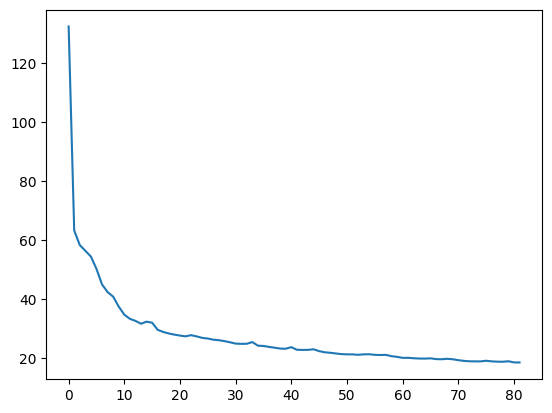

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/154 [00:00<?, ?it/s]

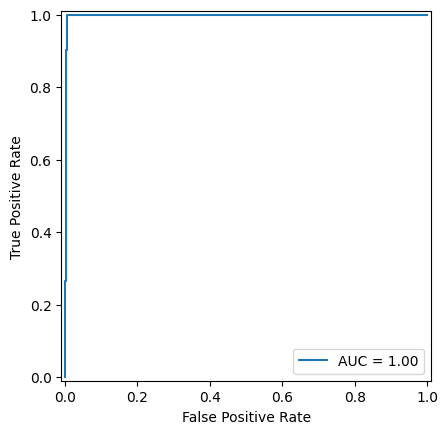

Evaluation on the test set ...


  0%|          | 0/3794 [00:00<?, ?it/s]

True Positive rate 0.930
True Neagtive rate: 0.916
ROC AUC score: 0.923


In [21]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
shape = next(iter(train_loader))[0].shape
model = VariationalAutoencoder(shape[1:], latent_dims)
model.to(device)

model, loss_history = train(model, train_loader, lr=learning_rate, epochs=epochs)

th, _, _, _ = det_threshold(model, val_loader, proliv_loader)

print("Evaluation on the test set ...")
y_true = [int(b[1]) for b in list(test_loader)]
tpr, tnr, roc_auc = test_eval(model, test_loader, y_true, 82.41)
print(
    f"True Positive rate {tpr:.3f}\nTrue Neagtive rate: {tnr:.3f}\nROC AUC score: {roc_auc:.3f}"
)

# Результат

True Positive rate: 0.930  
True Neagtive rate: 0.916   
ROC AUC score: 0.923    

# Эксперимент 1
Увеличим глубину сети. Добавим больше слоёв с различными размерностями в Encoder и Decoder как в AE, так и VAE. Это должно помочь сети захватить более сложные зависимости.   
Будем использовать параметры, рекомендованные optuna.

In [45]:
# AE
class Encoder(nn.Module):
    def __init__(self, input_dims, latent_dims):
        super(Encoder, self).__init__()
        self.linear1 = nn.Linear(input_dims, 1024)
        self.linear2 = nn.Linear(1024, 512)
        self.linear3 = nn.Linear(512, latent_dims)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        return self.linear3(x)

class Decoder(nn.Module):
    def __init__(self, out_dims, latent_dims, shape):
        super(Decoder, self).__init__()
        self.shape = shape
        self.linear1 = nn.Linear(latent_dims, 512)
        self.linear2 = nn.Linear(512, 1024)
        self.linear3 = nn.Linear(1024, out_dims)

    def forward(self, z):
        z = F.relu(self.linear1(z))
        z = F.relu(self.linear2(z))
        z = torch.sigmoid(self.linear3(z))
        return z.reshape((-1, *self.shape))

class Autoencoder1(nn.Module):
    def __init__(self, shape, latent_dims):
        super(Autoencoder1, self).__init__()
        self.shape = shape
        self.latent_dims = latent_dims
        self.input_dims = torch.prod(torch.tensor(self.shape))
        self.encoder = Encoder(self.input_dims, self.latent_dims)
        self.decoder = Decoder(self.input_dims, self.latent_dims, self.shape)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

# VAE
class VariationalEncoder(nn.Module):
    def __init__(self, input_dims, latent_dims):
        super(VariationalEncoder, self).__init__()
        self.linear1 = nn.Linear(input_dims, 1024)
        self.linear2 = nn.Linear(1024, 512)
        self.mu_layer = nn.Linear(512, latent_dims)
        self.sigma_layer = nn.Linear(512, latent_dims)

        self.N = torch.distributions.Normal(0, 1)
        self.N.loc = self.N.loc.to(device)
        self.N.scale = self.N.scale.to(device)
        self.kl = 0

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        mu = self.mu_layer(x)
        sigma = torch.exp(self.sigma_layer(x))
        z = mu + sigma * self.N.sample(mu.shape)
        self.kl = (sigma**2 + mu**2 - torch.log(sigma) - 1 / 2).sum()
        return z

class VariationalDecoder(nn.Module):
    def __init__(self, out_dims, latent_dims, shape):
        super(VariationalDecoder, self).__init__()
        self.shape = shape
        self.linear1 = nn.Linear(latent_dims, 512)
        self.linear2 = nn.Linear(512, 1024)
        self.linear3 = nn.Linear(1024, out_dims)

    def forward(self, z):
        z = F.relu(self.linear1(z))
        z = F.relu(self.linear2(z))
        z = torch.sigmoid(self.linear3(z))
        return z.reshape((-1, *self.shape))

class VariationalAutoencoder1(nn.Module):
    def __init__(self, shape, latent_dims):
        super(VariationalAutoencoder1, self).__init__()
        self.shape = shape
        self.latent_dims = latent_dims
        self.input_dims = torch.prod(torch.tensor(self.shape))
        self.encoder = VariationalEncoder(self.input_dims, self.latent_dims)
        self.decoder = VariationalDecoder(self.input_dims, self.latent_dims, self.shape)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [59]:
device = "cuda" if torch.cuda.is_available() else "cpu"

def run_epoch(model, data, mode="train", opt=None, show_pb=True):
    epoch_losses = []
    if show_pb:
        batches = tqdm(data)
    else:
        batches = data
    for x, y in batches:
        x = x.to(device)  # GPU
        if mode == "train":
            opt.zero_grad()
        x_hat = model(x)
        loss = ((x - x_hat) ** 2).sum() / data.batch_size
        epoch_losses.append(loss.item())
        if show_pb:
            batches.set_description(f"Loss: {loss.item():.4f}")
        if mode == "train" and opt:
            loss.backward()
            opt.step()
    return epoch_losses


def train(
    model, data, lr=0.001, epochs=20, plot=True, pb_for_each_epoch=True, to_wandb=False, title="example"
):
    model.to(device)
    model.train()
    loss_history = []
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    if to_wandb:
        wandb.init(project=title, config={"learning_rate": lr, "epochs": epochs})

    if not pb_for_each_epoch:
        epochs_range = trange(epochs)
    else:
        epochs_range = range(epochs)

    for epoch in epochs_range:
        if pb_for_each_epoch:
            print(f"Epoch: {epoch}")
        epoch_losses = run_epoch(
            model, data, mode="train", opt=opt, show_pb=pb_for_each_epoch
        )
        avg_epoch_loss = np.mean(epoch_losses)
        loss_history.append(avg_epoch_loss)

        if not pb_for_each_epoch:
            epochs_range.set_description(f"Avg Loss: {avg_epoch_loss:.4f}")
        elif not plot:
            print(f"Train loss: {avg_epoch_loss:.4f}")

        if to_wandb:
            wandb.log({"epoch": epoch, "loss": avg_epoch_loss})

        if plot:
            clear_output(wait=True)
            print(f"Epoch: {epoch}, Train loss: {avg_epoch_loss:.4f}")
            print("Loss curve")
            plt.plot(loss_history, label="Train Loss")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.legend()
            plt.show()

    if to_wandb:
        wandb.finish()

    return model, loss_history


def eval(model, data, to_wandb=False):
    model.eval()
    losses = run_epoch(model, data, mode="eval")
    avg_loss = np.mean(losses)
    
    if to_wandb:
        wandb.log({"eval_loss": avg_loss})
    
    print(f"Evaluation Loss: {avg_loss:.4f}")
    return losses


In [62]:
device = 'cuda'

learning_rate = 0.0003952110644697503
epochs = 82
batch_size = 780
latent_dims = 4

train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
shape = next(iter(train_loader))[0].shape
autoencoder1 = Autoencoder1(shape[1:], latent_dims)
vae1 = VariationalAutoencoder1(shape[1:], latent_dims).to(device)

Epoch: 81, Train loss: 21.3338
Loss curve


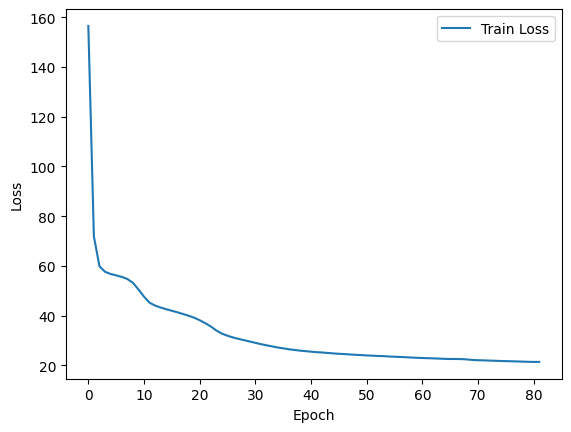

epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇███
loss,█▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,81
loss,21.33376


  0%|          | 0/500 [00:00<?, ?it/s]

Evaluation Loss: 23.6061


  0%|          | 0/154 [00:00<?, ?it/s]

Evaluation Loss: 83.8549


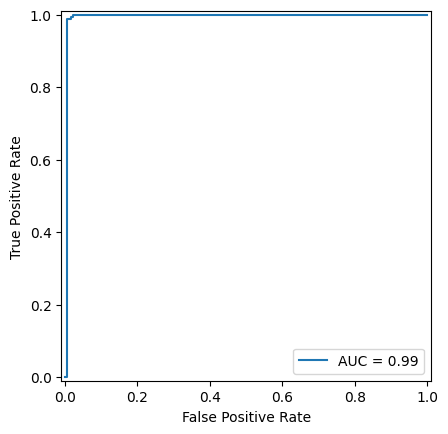

Evaluation on the test set ...


  0%|          | 0/3794 [00:00<?, ?it/s]

True Positive rate 0.822
True Neagtive rate: 0.914
ROC AUC score: 0.868


In [63]:
autoencoder1, loss_history = train(autoencoder1, train_loader, lr=learning_rate, epochs=epochs, title="AE-Experiment-1", to_wandb=True)
th, _, _, _ = det_threshold(autoencoder1, val_loader, proliv_loader)

print("Evaluation on the test set ...")
y_true = [int(b[1]) for b in list(test_loader)]
tpr, tnr, roc_auc = test_eval(autoencoder1, test_loader, y_true, 82.41)
print(
    f"True Positive rate {tpr:.3f}\nTrue Neagtive rate: {tnr:.3f}\nROC AUC score: {roc_auc:.3f}"
)

Epoch: 81, Train loss: 16.6335
Loss curve


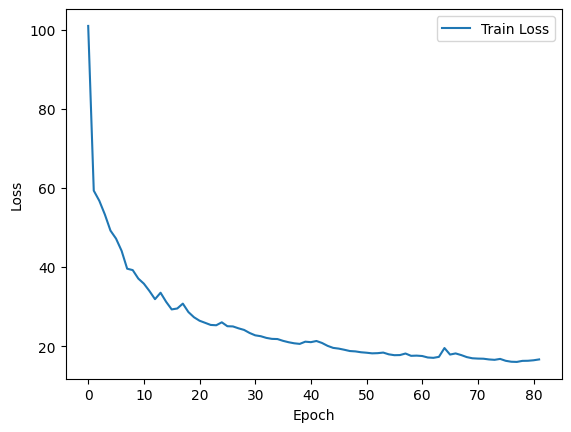

epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇██
loss,██▇▆▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁
epoch,81
loss,16.6335


  0%|          | 0/500 [00:00<?, ?it/s]

Evaluation Loss: 18.8796


  0%|          | 0/154 [00:00<?, ?it/s]

Evaluation Loss: 145.9924


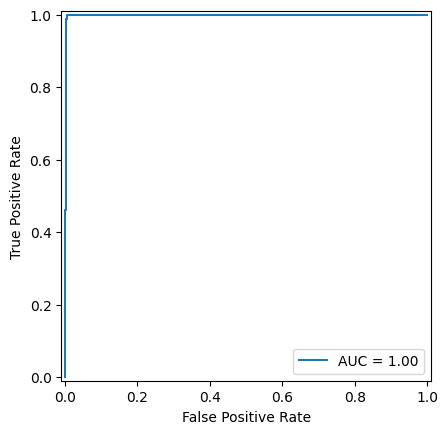

Evaluation on the test set ...


  0%|          | 0/3794 [00:00<?, ?it/s]

True Positive rate 0.922
True Neagtive rate: 0.764
ROC AUC score: 0.843


In [64]:
vae1, loss_history = train(vae1, train_loader, lr=learning_rate, epochs=epochs, title="AE-Experiment-1", to_wandb=True)
th, _, _, _ = det_threshold(vae1, val_loader, proliv_loader)

print("Evaluation on the test set ...")
y_true = [int(b[1]) for b in list(test_loader)]
tpr, tnr, roc_auc = test_eval(vae1, test_loader, y_true, 82.41)
print(
    f"True Positive rate {tpr:.3f}\nTrue Neagtive rate: {tnr:.3f}\nROC AUC score: {roc_auc:.3f}"
)

Результаты по сравнению с базовой архитектурой получились немного хуже. Думаю, что использование большого количества линейных слоев вызвало проблемы с запаздыванием сходимости. Видимо, cлишком маленькое латентное пространство заставило модель «сжимать» слишком много информации в ограниченное количество измерений, что и привило к недообучению.

# Эксперимент 2
Попробуем использовать иную архитектуру, которая будет содержать conv слои для выделения закономерности и на основе его попробуем получить более лучшие результаты.

In [202]:
class ConvEncoder(nn.Module):
    def __init__(self, latent_dims):
        super(ConvEncoder, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        self.flatten = nn.Flatten()
        # 256 * 3 * 4 = 3072
        self.fc_mu = nn.Linear(256 * 3 * 4, latent_dims)
        self.fc_sigma = nn.Linear(256 * 3 * 4, latent_dims)

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        mu = self.fc_mu(x)
        sigma = torch.exp(self.fc_sigma(x))  
        return mu, sigma


class ConvDecoder(nn.Module):
    def __init__(self, latent_dims):
        super(ConvDecoder, self).__init__()
        self.fc = nn.Linear(latent_dims, 256 * 3 * 4)
        self.unflatten = nn.Unflatten(1, (256, 3, 4))
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=(1, 1)), 
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=(0, 0)),  
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=(0, 1)),  
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=(0, 1)),  # ([B, 3, 41, 60])
            nn.Sigmoid(),
        )

        self.adjust_to_target = nn.Sequential(
            nn.Flatten(1),  
            nn.Linear(3 * 41 * 60, 3 * 33 * 53),  
            nn.Unflatten(1, (3, 33, 53))
        )

    def forward(self, z):
        z = self.fc(z)
        z = self.unflatten(z)
        z = self.deconv(z)
        return self.adjust_to_target(z)


class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dims):
        super(VariationalAutoencoder, self).__init__()
        self.encoder = ConvEncoder(latent_dims)        
        self.decoder = ConvDecoder(latent_dims)
        self.N = torch.distributions.Normal(0, 1)
        self.kl = 0

    def forward(self, x):
        mu, sigma = self.encoder(x)
        z = mu + sigma * self.N.sample(mu.shape).to(x.device)
        self.kl = (sigma**2 + mu**2 - torch.log(sigma) - 1 / 2).sum()
        return self.decoder(z)

Epoch: 81, Train loss: 18.4535
Loss curve


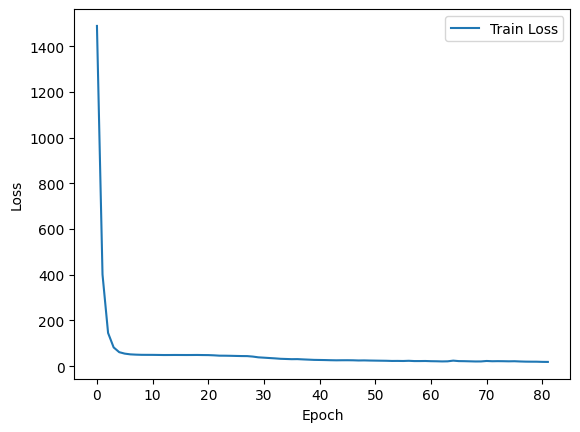

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
loss,█▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,81
loss,18.45353


  0%|          | 0/500 [00:00<?, ?it/s]

Evaluation Loss: 28.5173


  0%|          | 0/154 [00:00<?, ?it/s]

Evaluation Loss: 73.1304


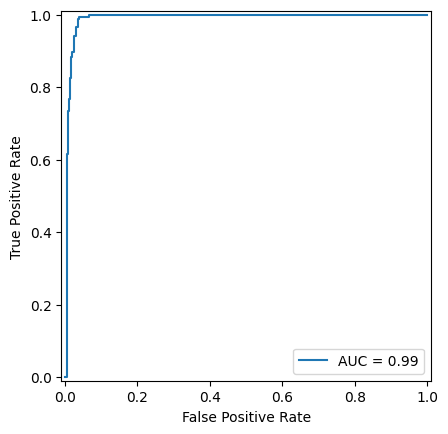

Evaluation on the test set ...


  0%|          | 0/3794 [00:00<?, ?it/s]

True Positive rate 0.605
True Neagtive rate: 0.828
ROC AUC score: 0.716


In [204]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
convVae = VariationalAutoencoder(latent_dims=4).to(device)
convVae, loss_history = train(convVae, train_loader, lr=learning_rate, epochs=epochs, title="AE-Experiment-2", to_wandb=True)
th, _, _, _ = det_threshold(convVae, val_loader, proliv_loader)

print("Evaluation on the test set ...")
y_true = [int(b[1]) for b in list(test_loader)]
tpr, tnr, roc_auc = test_eval(convVae, test_loader, y_true, 82.41)
print(
    f"True Positive rate {tpr:.3f}\nTrue Neagtive rate: {tnr:.3f}\nROC AUC score: {roc_auc:.3f}"
)

Результаты по сравнению с базовой архитектурой получились значительно хуже. Видимо, из-за слишком агрессивной свертки или малой ширины каналов инофрмация теряется.